# 06. PyTorch Transfer Learning Exercises

Welcome to the 06. PyTorch Transfer Learning exercise template notebook.

There are several questions in this notebook and it's your goal to answer them by writing Python and PyTorch code.

> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.

## Resources and solutions

* These exercises/solutions are based on [section 06. PyTorch Transfer Learning](https://www.learnpytorch.io/06_pytorch_transfer_learning/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.

**Solutions:**

Try to complete the code below *before* looking at these.

* See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/ueLolShyFqs).
* See an example [solutions notebook for these exercises on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/06_pytorch_transfer_learning_exercise_solutions.ipynb).

## 1. Make predictions on the entire test dataset and plot a confusion matrix for the results of our model compared to the truth labels.
* **Note:** You will need to get the dataset and the trained model/retrain the model from notebook 06 to perform predictions.
* Check out [03. PyTorch Computer Vision section 10](https://www.learnpytorch.io/03_pytorch_computer_vision/#10-making-a-confusion-matrix-for-further-prediction-evaluation) for ideas.

In [1]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms, datasets
from torchinfo import summary
from going_modular.going_modular.data_setup import create_dataloaders
from going_modular.going_modular.engine import train_test_step

/home/jojo/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Get data

In [3]:
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

### Prepare data

In [4]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [5]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=train_dir,
                                                                    test_dir=test_dir,
                                                                    transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                    batch_size=32,
                                                                    num_workers=2) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


(<torch.utils.data.dataloader.DataLoader at 0x7ada87b32000>,
 ['pizza', 'steak', 'sushi'])

### Get and prepare a pretrained model

In [6]:
# Setup the model with pretrained weights and send it to the target device
model = torchvision.models.efficientnet_b0(weights="DEFAULT").to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [7]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model.features.parameters():
    param.requires_grad = False

In [8]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

In [9]:
from going_modular.going_modular.utils import load_model

model_0 = load_model(model_builder=model,
                     model_path="models/06_pytorch_transfer_learning_model.pth",
                     device=device)
model_0

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Make predictions on the entire test dataset with the model

In [10]:

# 1. Make predictions with trained model
from tqdm.auto import tqdm

y_preds = []
model_0.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_0(X)
    # Put predictions on CPU for evaluation
    y_preds.append(y_logit.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)
# Turn predictions from logits -> prediction probabilities -> predictions labels
y_pred_tensor = torch.argmax(y_pred_tensor, dim=1) 

Making predictions:   0%|          | 0/3 [00:00<?, ?it/s]

### Make a confusion matrix with the test preds and the truth labels

Need the following libraries to make a confusion matrix:
* torchmetrics - https://torchmetrics.readthedocs.io/en/stable/
* mlxtend - http://rasbt.github.io/mlxtend/

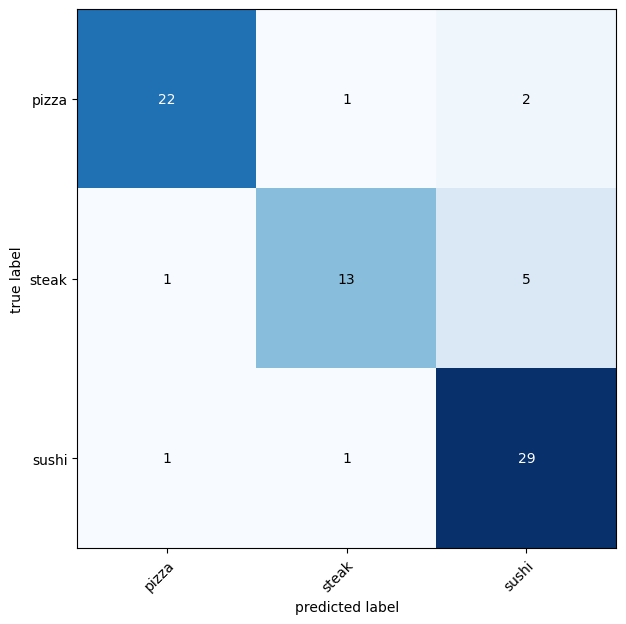

In [11]:
# See if torchmetrics exists, if not, install it
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=torch.tensor(test_dataloader.dataset.targets))

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy 
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
)

## 2. Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

You'll want to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

In [12]:
y_pred_tensor

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 0, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
        2, 2, 2])

In [13]:
# 1. Make predictions with trained model
from tqdm.auto import tqdm

y_preds_prob_max = []
all_logits = []
model_0.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X = X.to(device)
        logits = model_0(X)
        all_logits.append(logits.cpu())
# Concaténer tous les logits
all_logits = torch.cat(all_logits)
# Calculer les probabilités via softmax
all_probs = torch.softmax(all_logits, dim=1)
# Indices des classes prédites
all_preds = torch.argmax(all_probs, dim=1)
# Probabilités maximales pour chaque échantillon
y_pred_probs_tensor = all_probs[range(len(all_preds)), all_preds]
y_truth_probs_tensor = all_probs[range(len(all_preds)), test_dataloader.dataset.targets]
y_pred_probs_tensor

Making predictions:   0%|          | 0/3 [00:00<?, ?it/s]

tensor([0.7165, 0.7733, 0.7561, 0.8777, 0.5716, 0.4207, 0.8301, 0.8276, 0.8171,
        0.8845, 0.6513, 0.6315, 0.6788, 0.4624, 0.6599, 0.4549, 0.7975, 0.6563,
        0.8891, 0.8892, 0.6528, 0.5615, 0.6024, 0.7267, 0.7024, 0.8651, 0.8705,
        0.4809, 0.9461, 0.4258, 0.8058, 0.9208, 0.7686, 0.4087, 0.6885, 0.7889,
        0.8359, 0.4703, 0.4768, 0.9134, 0.8515, 0.7622, 0.9215, 0.5697, 0.8528,
        0.4382, 0.7762, 0.8046, 0.9519, 0.9609, 0.8376, 0.6206, 0.6374, 0.5944,
        0.9669, 0.7026, 0.6818, 0.5893, 0.5477, 0.7783, 0.4851, 0.9681, 0.7523,
        0.6564, 0.6714, 0.6669, 0.6119, 0.8209, 0.6411, 0.8461, 0.5507, 0.7775,
        0.5377, 0.5373, 0.6842])

In [14]:
y_pred_probs_numpy = y_pred_probs_tensor.numpy()
y_truth_probs_numpy = y_truth_probs_tensor.numpy()
y_pred_numpy = y_pred_tensor.numpy()
test_pred = test_dataloader.dataset.targets

In [15]:
import pandas as pd
df = pd.DataFrame({"y_pred_probs": y_pred_probs_numpy,
                   "y_truth_probs": y_truth_probs_numpy,
                   "y_pred_error": y_pred_probs_numpy - y_truth_probs_numpy,
                   "y_pred": y_pred_numpy,
                   "y_true": test_pred})
df

,y_pred_probs,y_truth_probs,y_pred_error,y_pred,y_true
0,0.716483,0.716483,0.00000,0,0
1,0.773259,0.773259,0.00000,0,0
2,0.756056,0.756056,0.00000,0,0
3,0.877659,0.877659,0.00000,0,0
4,0.571597,0.571597,0.00000,0,0
...,...,...,...,...,...
70,0.550697,0.322417,0.22828,1,2
71,0.777528,0.777528,0.00000,2,2
72,0.537697,0.537697,0.00000,2,2
73,0.537349,0.537349,0.00000,2,2


In [16]:
df_five_most_wrong = df[df["y_pred"] != df["y_true"]].sort_values(by="y_pred_error", ascending=False).head(5)
df_five_most_wrong

,y_pred_probs,y_truth_probs,y_pred_error,y_pred,y_true
12,0.678778,0.116026,0.562752,2,0
34,0.688470,0.229517,0.458953,2,1
43,0.569710,0.308495,0.261215,2,1
70,0.550697,0.322417,0.228280,1,2
38,0.476827,0.313562,0.163265,2,1


In [17]:
def img_denorm(tensor_image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    tensor_image = tensor_image * std + mean
    tensor_image = tensor_image.permute(1,2,0)
    tensor_image = np.clip(tensor_image,0,1)
    return tensor_image

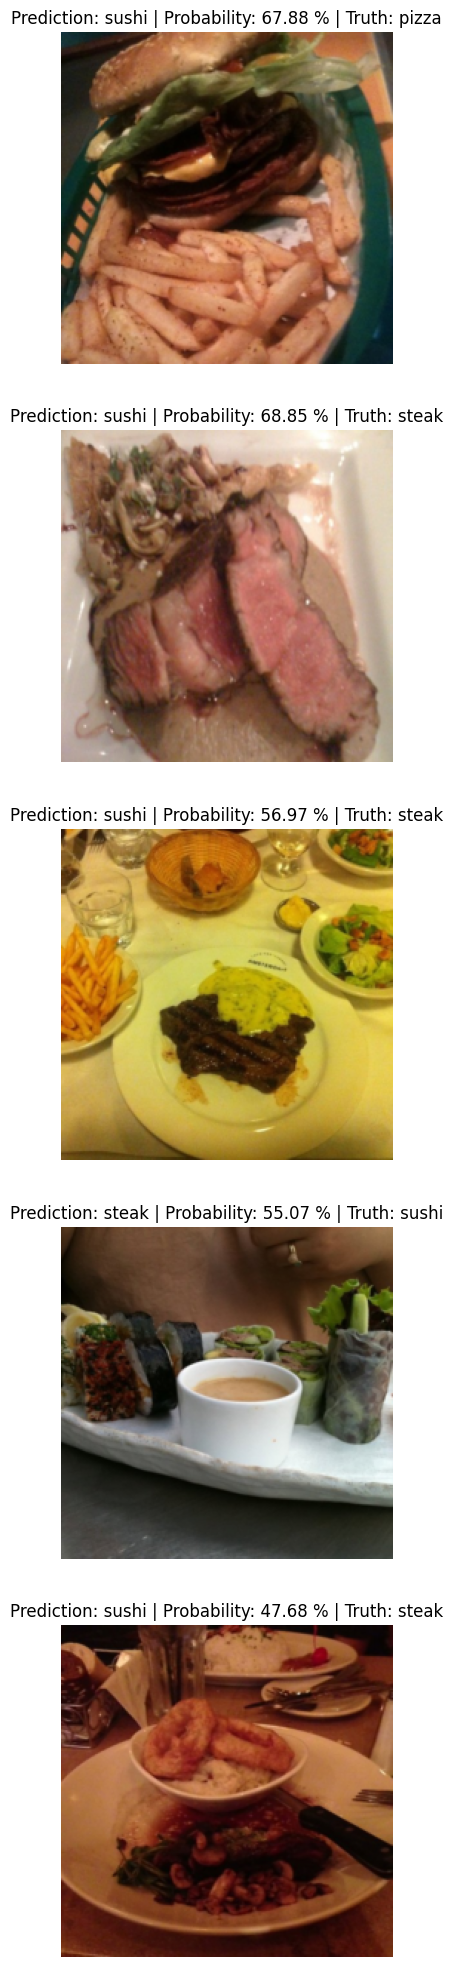

In [18]:
fig = plt.figure(figsize=(25,25))
rows, cols = 5, 1
for i, row in enumerate(df_five_most_wrong.itertuples()):
    tensor = test_dataloader.dataset[row[0]][0]
    fig.add_subplot(rows, cols, i+1)
    plt.imshow(img_denorm(tensor))
    plt.title(f"Prediction: {class_names[row[4]]} | Probability: {row[1]*100:.2f} % | Truth: {class_names[row[5]]}")
    plt.axis("off")

## 3. Predict on your own image of pizza/steak/sushi - how does the model go? What happens if you predict on an image that isn't pizza/steak/sushi?
* Here you can get an image from a website like http://www.unsplash.com to try it out or you can upload your own.

In [19]:
# TODO: Get an image of pizza/steak/sushi


In [20]:
# TODO: Get an image of not pizza/steak/sushi


## 4. Train the model from section 4  in notebook 06 part 3 for longer (10 epochs should do), what happens to the performance?

* See the model in notebook 06 part 3 for reference: https://www.learnpytorch.io/06_pytorch_transfer_learning/#3-getting-a-pretrained-model

In [21]:
# TODO: Recreate a new model


In [22]:
# TODO: Train the model for 10 epochs

## 5. Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb).


### Get 20% data

In [23]:
from going_modular.going_modular.data_import import get_data

get_data(url="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
         file="pizza_steak_sushi_20_percent.zip")       

Did not find data/pizza_steak_sushi_20_percent.zip directory, creating one...


### Create DataLoaders

In [24]:
import os
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader_20_percent, test_dataloader_20_percent, class_names = create_dataloaders(train_dir="data/pizza_steak_sushi_20_percent/train",
                                                                                          test_dir="data/pizza_steak_sushi_20_percent/test",
                                                                                          transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                                          batch_size=32,
                                                                                         ) # set mini-batch size to 32

train_dataloader_20_percent, test_dataloader_20_percent, class_names

Train data:
Dataset ImageFolder
    Number of datapoints: 450
    Root location: data/pizza_steak_sushi_20_percent/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 150
    Root location: data/pizza_steak_sushi_20_percent/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


(<torch.utils.data.dataloader.DataLoader at 0x7ada31f9b2c0>,
 ['pizza', 'steak', 'sushi'])

### Train a model with 20% of the data

In [30]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_test_step(model=model,
                train_dataloader=train_dataloader_20_percent,
                test_dataloader=test_dataloader_20_percent,
                loss_fn=loss_fn,
                optimizer=optimizer,
                device=device,
                epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/450 samples
Train loss: 0.502 | Train accuracy: 82.71%
Test loss: 0.350 | Test accuracy: 93.18%
Epoch 1
-------
Looked at 0/450 samples
Train loss: 0.415 | Train accuracy: 87.50%
Test loss: 0.320 | Test accuracy: 92.27%
Epoch 2
-------
Looked at 0/450 samples
Train loss: 0.412 | Train accuracy: 86.25%
Test loss: 0.298 | Test accuracy: 92.56%
Epoch 3
-------
Looked at 0/450 samples
Train loss: 0.325 | Train accuracy: 90.62%
Test loss: 0.290 | Test accuracy: 93.47%
Epoch 4
-------
Looked at 0/450 samples
Train loss: 0.346 | Train accuracy: 89.79%
Test loss: 0.284 | Test accuracy: 91.65%
Epoch 5
-------
Looked at 0/450 samples
Train loss: 0.356 | Train accuracy: 85.83%
Test loss: 0.278 | Test accuracy: 90.40%
Epoch 6
-------
Looked at 0/450 samples
Train loss: 0.353 | Train accuracy: 85.00%
Test loss: 0.247 | Test accuracy: 93.52%
Epoch 7
-------
Looked at 0/450 samples
Train loss: 0.348 | Train accuracy: 86.04%
Test loss: 0.263 | Test accuracy: 90.40%
Epoch 8


{'train_loss': [0.5018399953842163,
  0.4153464138507843,
  0.4124321937561035,
  0.3253749907016754,
  0.3459189236164093,
  0.3563216030597687,
  0.3525131344795227,
  0.34766361117362976,
  0.26339852809906006,
  0.30447694659233093],
 'train_acc': [82.70833333333333,
  87.5,
  86.25,
  90.625,
  89.79166666666667,
  85.83333333333333,
  85.0,
  86.04166666666667,
  89.79166666666667,
  91.45833333333333],
 'test_loss': [0.3496722877025604,
  0.32009559869766235,
  0.29801619052886963,
  0.2896260917186737,
  0.284321129322052,
  0.27764686942100525,
  0.24719634652137756,
  0.26265716552734375,
  0.2596513032913208,
  0.2265443056821823],
 'test_acc': [93.18181818181817,
  92.27272727272728,
  92.55681818181817,
  93.4659090909091,
  91.64772727272728,
  90.39772727272728,
  93.52272727272728,
  90.39772727272728,
  91.36363636363636,
  92.89772727272728]}

## 6. Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [34]:
from torchvision.models import EfficientNet_B2_Weights, efficientnet_b2
weights = EfficientNet_B2_Weights.DEFAULT
model = efficientnet_b2(weights=weights).to(device)
simple_transform = weights.transforms()
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [37]:
for param in model.features.parameters():
    param.requires_grad = False

In [35]:
train_dataloader_20_percent, test_dataloader_20_percent, class_names = create_dataloaders(train_dir="data/pizza_steak_sushi_20_percent/train",
                                                                                          test_dir="data/pizza_steak_sushi_20_percent/test",
                                                                                          transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                                          batch_size=32,
                                                                                         ) # set mini-batch size to 32

Train data:
Dataset ImageFolder
    Number of datapoints: 450
    Root location: data/pizza_steak_sushi_20_percent/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[288]
               resize_size=[288]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 150
    Root location: data/pizza_steak_sushi_20_percent/test
    StandardTransform
Transform: ImageClassification(
               crop_size=[288]
               resize_size=[288]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )


In [38]:
model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1408,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)


train_test_step(model=model,
                train_dataloader=train_dataloader_20_percent,
                test_dataloader=test_dataloader_20_percent,
                loss_fn=loss_fn,
                optimizer=optimizer,
                device=device,
                epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/450 samples
Train loss: 1.117 | Train accuracy: 32.92%
Test loss: 1.094 | Test accuracy: 32.84%
Epoch 1
-------
Looked at 0/450 samples
Train loss: 1.116 | Train accuracy: 31.25%
Test loss: 1.092 | Test accuracy: 40.51%
Epoch 2
-------
Looked at 0/450 samples
Train loss: 1.119 | Train accuracy: 30.00%
Test loss: 1.093 | Test accuracy: 39.66%
Epoch 3
-------
Looked at 0/450 samples
Train loss: 1.124 | Train accuracy: 31.04%
Test loss: 1.096 | Test accuracy: 38.35%
Epoch 4
-------
Looked at 0/450 samples
Train loss: 1.121 | Train accuracy: 33.12%
Test loss: 1.092 | Test accuracy: 39.89%
Epoch 5
-------
Looked at 0/450 samples
Train loss: 1.118 | Train accuracy: 28.96%
Test loss: 1.096 | Test accuracy: 40.11%
Epoch 6
-------
Looked at 0/450 samples
Train loss: 1.114 | Train accuracy: 34.58%
Test loss: 1.095 | Test accuracy: 39.26%
Epoch 7
-------
Looked at 0/450 samples
Train loss: 1.111 | Train accuracy: 37.08%
Test loss: 1.094 | Test accuracy: 38.98%
Epoch 8


{'train_loss': [1.1170638799667358,
  1.1155990362167358,
  1.1193991899490356,
  1.1243938207626343,
  1.1206691265106201,
  1.117556095123291,
  1.1138520240783691,
  1.1112154722213745,
  1.1242172718048096,
  1.1129066944122314],
 'train_acc': [32.916666666666664,
  31.25,
  30.0,
  31.041666666666668,
  33.125,
  28.958333333333332,
  34.583333333333336,
  37.083333333333336,
  32.083333333333336,
  32.5],
 'test_loss': [1.0940637588500977,
  1.0924794673919678,
  1.0928611755371094,
  1.0962580442428589,
  1.0919562578201294,
  1.095955491065979,
  1.0950275659561157,
  1.0942420959472656,
  1.0942152738571167,
  1.0961090326309204],
 'test_acc': [32.840909090909086,
  40.51136363636364,
  39.65909090909091,
  38.35227272727273,
  39.88636363636364,
  40.11363636363636,
  39.26136363636364,
  38.97727272727273,
  40.56818181818182,
  39.31818181818182]}